In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from sympy import lambdify
import sympy as sp

# 1. Point Python to your exact SRC directory
sys.path.append("/Users/adarshmac/simulations/bbh_run1/ANALYTICAL_CODES/SRC")

# 2. Import your engine
from SymbolicEngine import calculate_automated_fields

# 3. Execute the engine
print("Starting exact tensor calculations...")
results = calculate_automated_fields()

# 4. Extract matrices and symbols for plotting
E_hat = results['E_hat']
rho_hat = results['rho_hat']
q_hat = results['q_hat']

r = results['symbols']['r']
theta = results['symbols']['theta']
M = results['symbols']['M']

Starting exact tensor calculations...
Executing Symbolic Tensor Engine...
Calculations Complete.


Lambdifying exact symbolic expressions into NumPy functions...
Setting up grid and evaluating...
Rendering Plots...


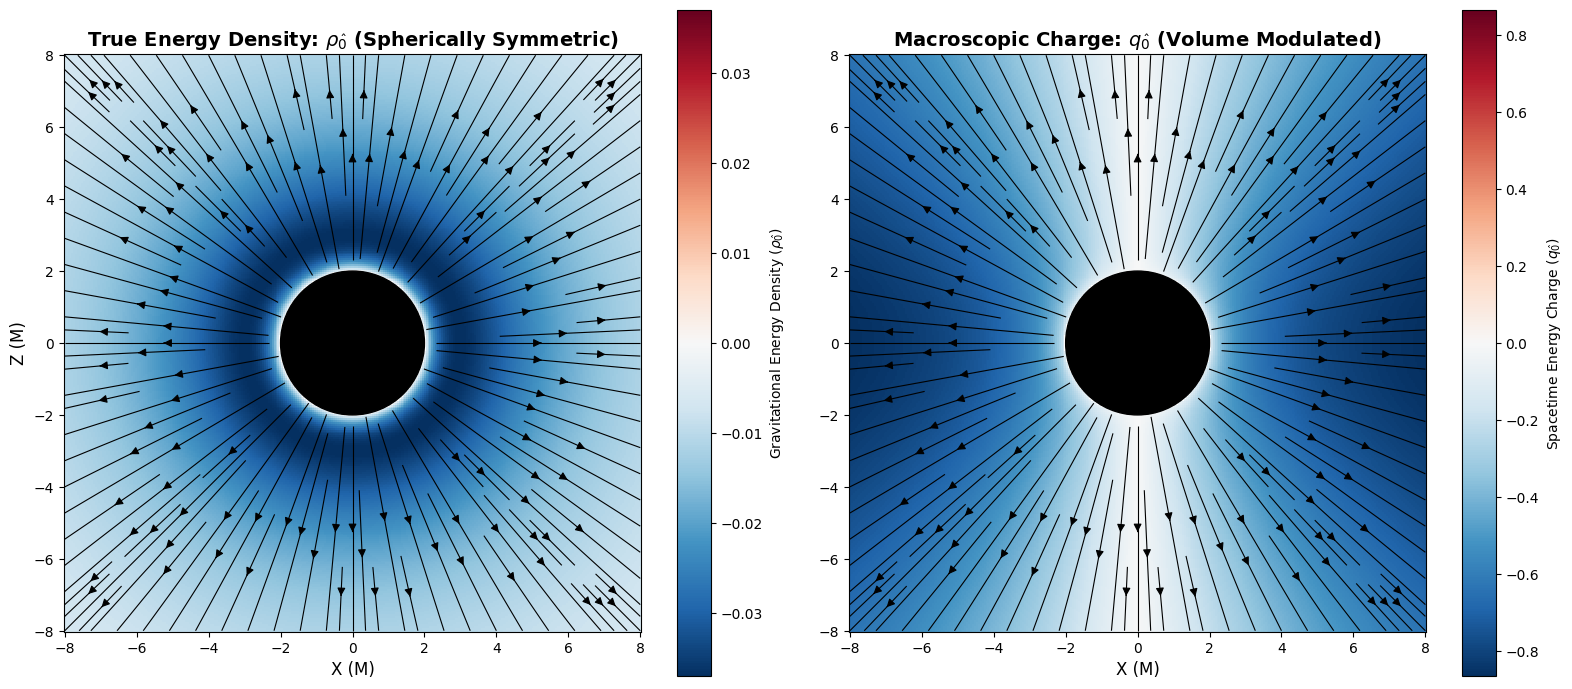

In [6]:
def plot_analytical_fields(E_hat, q_hat, rho_hat, r_sym, theta_sym, M_sym, M_val=1.0):
    print("Lambdifying exact symbolic expressions into NumPy functions...")
    
    # Substitute Mass value into expressions
    E_r_expr = sp.simplify(E_hat[0, 1].subs(M_sym, M_val))
    E_theta_expr = sp.simplify(E_hat[0, 2].subs(M_sym, M_val))
    q0_expr = sp.simplify(q_hat[0].subs(M_sym, M_val))
    rho0_expr = sp.simplify(rho_hat[0].subs(M_sym, M_val))
    
    # Compile to fast C/NumPy functions
    E_r_func = lambdify((r_sym, theta_sym), E_r_expr, "numpy")
    E_theta_func = lambdify((r_sym, theta_sym), E_theta_expr, "numpy")
    q0_func = lambdify((r_sym, theta_sym), q0_expr, "numpy")
    rho0_func = lambdify((r_sym, theta_sym), rho0_expr, "numpy")
    
    print("Setting up grid and evaluating...")
    grid_lim = 8.0
    resolution = 300
    x_vals = np.linspace(-grid_lim, grid_lim, resolution)
    z_vals = np.linspace(-grid_lim, grid_lim, resolution)
    X, Z = np.meshgrid(x_vals, z_vals)
    
    R = np.sqrt(X**2 + Z**2)
    R = np.where(R < 1e-5, 1e-5, R) 
    Theta = np.arccos(Z / R)
    
    rs_val = 2.0 * M_val
    mask = R > (1.01 * rs_val)
    
    R_safe = np.where(mask, R, 1.01 * rs_val)
    Theta_safe = np.where(mask, Theta, np.pi/2)
    
    # Vectorized evaluation
    E_r_num = np.zeros_like(R)
    E_theta_num = np.zeros_like(R)
    q0_num = np.zeros_like(R)
    rho0_num = np.zeros_like(R)
    
    E_r_num[mask] = E_r_func(R_safe[mask], Theta_safe[mask])
    E_theta_num[mask] = E_theta_func(R_safe[mask], Theta_safe[mask])
    q0_num[mask] = q0_func(R_safe[mask], Theta_safe[mask])
    rho0_num[mask] = rho0_func(R_safe[mask], Theta_safe[mask])
    
    # Correct 3D to 2D Projection
    sign_x = np.sign(X)
    sign_x[sign_x == 0] = 1.0 
    
    Ex = (E_r_num * np.sin(Theta) + E_theta_num * np.cos(Theta)) * sign_x
    Ez = E_r_num * np.cos(Theta) - E_theta_num * np.sin(Theta)
    
    # Apply Horizon Mask
    Ex[~mask] = np.nan
    Ez[~mask] = np.nan
    q0_num[~mask] = np.nan
    rho0_num[~mask] = np.nan

    print("Rendering Plots...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Panel 1: Physical Density
    ax1 = axes[0]
    rho_max = np.nanmax(np.abs(rho0_num))
    if np.isnan(rho_max) or rho_max == 0: rho_max = 1.0
    cmap1 = ax1.pcolormesh(X, Z, rho0_num, shading='auto', cmap='RdBu_r', vmin=-rho_max, vmax=rho_max)
    fig.colorbar(cmap1, ax=ax1, label=r"Gravitational Energy Density ($\rho_{\hat{0}}$)")
    ax1.streamplot(x_vals, z_vals, Ex, Ez, color='black', density=1.5, linewidth=0.8, arrowsize=1.2)
    ax1.add_patch(plt.Circle((0, 0), rs_val, color='black', zorder=10))
    ax1.set_aspect('equal')
    ax1.set_title(r"True Energy Density: $\rho_{\hat{0}}$ (Spherically Symmetric)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("X (M)", fontsize=12)
    ax1.set_ylabel("Z (M)", fontsize=12)

    # Panel 2: Macroscopic Charge
    ax2 = axes[1]
    q_max = np.nanmax(np.abs(q0_num))
    if np.isnan(q_max) or q_max == 0: q_max = 1.0 
    cmap2 = ax2.pcolormesh(X, Z, q0_num, shading='auto', cmap='RdBu_r', vmin=-q_max, vmax=q_max)
    fig.colorbar(cmap2, ax=ax2, label=r"Spacetime Energy Charge ($q_{\hat{0}}$)")
    ax2.streamplot(x_vals, z_vals, Ex, Ez, color='black', density=1.5, linewidth=0.8, arrowsize=1.2)
    ax2.add_patch(plt.Circle((0, 0), rs_val, color='black', zorder=10))
    ax2.set_aspect('equal')
    ax2.set_title(r"Macroscopic Charge: $q_{\hat{0}}$ (Volume Modulated)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("X (M)", fontsize=12)

    plt.tight_layout()
    plt.show()

    # Pass the required SymPy objects into the plotting function
plot_analytical_fields(E_hat, q_hat, rho_hat, r, theta, M, M_val=1.0)